# 01. 공식 평가식 재현과 데이터 감사

> 작성일: 2026-07-06 KST  
> 목적: 공식 `evaluation_metric.ipynb`를 재현하고, metric이 실제 데이터의 어떤 구간을 평가하는지 label, submission, weather metadata 기준으로 확인한다.

이 노트북은 **데이터분석 산출물**이다. 코드 모듈은 `src/baram/metrics.py`에 두고, 여기서는 공식 코드 대조, 데이터 파악, 결측치, capacity 범위, valid mask, 시각화, Decision Box를 함께 남긴다.

이번 노트북에서 하지 않는 것:

- 리더보드 제출
- 제출 CSV 저장
- LightGBM/CatBoost 구현
- SCADA feature 구현
- 외부 데이터 사용

## 목차

1. 실행 환경과 한글 표시 설정
2. 공식 평가 코드 구조 판독
3. 공식 metric 함수와 포팅 함수의 synthetic 대조
4. 공식 데이터 inventory와 제출 형식 점검
5. label 결측치, 범위, capacity violation 감사
6. 평가 valid mask가 데이터에서 차지하는 구간 시각화
7. naive holdout으로 metric 감각 확인
8. Decision Box와 다음 작업

## Decision Box 0: 분석 기준

| 항목 | 결정 | 이유 |
|---|---|---|
| 데이터분석 산출물 | 반드시 `.ipynb` | 데이터 파악, 시각화, 의사결정 로그는 실행 결과와 함께 보존해야 한다. |
| metric 기준 | 공식 `evaluation_metric.ipynb` | 대회 서버와 local validation의 기준을 맞추는 첫 단추다. |
| 평가 대상 | `actual >= capacity * 0.10` | 실제 발전량이 설비용량 10% 이상인 시간만 점수에 들어간다. |
| prediction 후처리 | metric 내부에서 하지 않음 | 공식 코드가 pred 음수/초과를 수정하지 않으므로 validator/후처리 책임으로 분리한다. |
| capacity 초과 actual | 공식 metric에서는 그대로 사용 | label 오류로 단정하지 않고 metric 동작을 우선 재현한다. |
| 한글 표시 | 노트북 시작부에서 폰트 설정 | 로컬/리뷰 화면에서 한글 제목과 축 라벨 깨짐을 줄인다. |

In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "open"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

sns.set_theme(style="whitegrid")
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print("프로젝트 루트:", PROJECT_ROOT)
print("선택된 한글 표시 폰트:", selected_font)
print("데이터 폴더 존재:", DATA_DIR.exists())
print("대상 컬럼:", TARGET_COLS)
print("capacity kWh:", CAPACITY_KWH)

OFFICIAL_METRIC_NOTEBOOK = PROJECT_ROOT / "references" / "official" / "notebooks" / "evaluation_metric.ipynb"
MANIFEST_PATH = DATA_DIR / "MANIFEST.md"

프로젝트 루트: C:\Users\kik32\workspace\Dacon\2026-BARAM-Wind-Power-Prediction-AI-Competition
선택된 한글 표시 폰트: Malgun Gothic
데이터 폴더 존재: True
대상 컬럼: ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']
capacity kWh: {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}


### 해석: 실행 환경을 먼저 고정한 이유

이 노트북은 결과 표와 그래프가 다음 세션에도 그대로 읽혀야 하므로, 첫 셀에서 프로젝트 루트, `src` import 경로, matplotlib 한글 폰트를 명시적으로 고정했다. 여기서 한글 폰트를 잡는 것은 장식이 아니라 분석 품질 조건이다. 축 제목과 Decision Box가 깨지면 이후 팀원이 같은 결과를 해석할 수 없기 때문이다.

다음 판단은 단순하다. 이후 모든 데이터분석 노트북은 같은 환경 셀을 출발점으로 사용하고, 표·시각화·해석 문단이 함께 실행 결과로 남아야 한다.

## 1. 공식 평가 코드 구조 판독

공식 노트북은 하나의 code cell에 metric 함수를 제공한다. 중요한 점은 row key merge를 하지 않고, `answer_df[col]`과 `pred_df[col]`의 현재 행 순서를 그대로 비교한다는 점이다.

In [2]:
official_notebook = json.loads(OFFICIAL_METRIC_NOTEBOOK.read_text(encoding="utf-8"))
official_code_cells = [cell for cell in official_notebook["cells"] if cell.get("cell_type") == "code"]
print("공식 metric 노트북 code cell 수:", len(official_code_cells))
print("공식 metric 코드:")
print("".join(official_code_cells[0].get("source", [])))

공식 metric 노트북 code cell 수: 1
공식 metric 코드:
import numpy as np

TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]

CAPACITY_KWH = {
    "kpx_group_1": 21600,
    "kpx_group_2": 21600,
    "kpx_group_3": 21000,
}


def metric(answer_df, pred_df):
    group_nmae = []
    group_ficr = []

    for col in TARGET_COLS:
        actual = answer_df[col].to_numpy(dtype=float)
        forecast = pred_df[col].to_numpy(dtype=float)
        capacity = CAPACITY_KWH[col]

        # 실제 발전량이 설비용량의 10% 이상인 시간대만 평가
        valid = actual >= capacity * 0.10

        actual = actual[valid]
        forecast = forecast[valid]

        # NMAE 계산
        error_rate = np.abs(forecast - actual) / capacity
        group_nmae.append(np.mean(error_rate))

        # FICR 계산
        unit_price = np.select(
            [error_rate <= 0.06, error_rate <= 0.08],
            [4.0, 3.0],
            default=0.0,
        )

        earned_settlement = np.sum(actual * unit_price)
        max_settlement = np.sum(actu

### 해석: 공식 코드에서 반드시 그대로 가져와야 하는 부분

공식 metric은 복잡한 wrapper 없이 세 target 컬럼을 순서대로 순회한다. 핵심은 `actual >= capacity * 0.10` 필터가 실제 발전량 기준이라는 점, 그리고 예측값을 metric 내부에서 절대 보정하지 않는다는 점이다. 즉 음수 예측이나 capacity 초과 예측은 여기서 고쳐지는 문제가 아니라 제출 생성 전 validator와 후처리에서 막아야 하는 문제다.

이 구조 때문에 local validation도 전체 시간 MAE만 보면 안 된다. 실제 점수는 고발전 valid 구간 중심으로 계산되고, FICR는 6%와 8% 경계 안에 들어온 row의 actual 가중 정산액으로 결정된다.

### 공식 metric 계산 순서

| 순서 | 계산 | 비고 |
|---:|---|---|
| 1 | target 컬럼 3개 순회 | `kpx_group_1/2/3` |
| 2 | `actual >= capacity * 0.10` valid mask 적용 | 10% 경계 포함 |
| 3 | `error_rate = abs(pred - actual) / capacity` | pred clipping 없음 |
| 4 | 그룹별 NMAE 평균 | valid row만 사용 |
| 5 | FICR 단가 부여 | `<=6%: 4`, `<=8%: 3`, 그 외 0 |
| 6 | 그룹별 FICR 계산 | `sum(actual * unit_price) / sum(actual * 4)` |
| 7 | 세 그룹 평균 후 total score | `0.5 * one_minus_nmae + 0.5 * ficr` |

### 해석: 산식은 평균오차와 정산구간을 동시에 묻는다

`1-NMAE`는 평균적인 capacity-normalized error를 본다. 반면 FICR는 모든 오차가 조금씩 줄어드는 것보다 6%·8% 경계 안으로 들어오는 시간이 얼마나 actual 발전량 가중으로 많아지는지를 본다. 그래서 이 대회는 단순 회귀 문제가 아니라, valid 구간과 경계 구간을 함께 관리해야 하는 문제다.

이후 실험표에는 최소한 `total_score`, `one_minus_nmae`, `ficr`, target별 valid NMAE, 6%/8% 안착률을 같이 기록해야 한다.

In [3]:
def load_official_metric():
  namespace = {}
  for cell in official_notebook["cells"]:
    if cell.get("cell_type") == "code":
      exec("".join(cell.get("source", [])), namespace)
  return namespace["metric"]


def call_ignoring_official_warnings(func, answer_df, pred_df):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    return func(answer_df, pred_df)


official_metric = load_official_metric()
print("공식 metric 함수 로드 완료:", callable(official_metric))

공식 metric 함수 로드 완료: True


## 2. synthetic edge case로 공식 코드와 포팅 코드 대조

아래 입력은 의도적으로 경계값과 비정상값을 섞었다.

- actual이 정확히 10% capacity인 행
- actual이 10% 미만이라 제외되는 행
- pred가 음수인 행
- pred가 capacity를 초과하는 행
- actual/pred NaN
- Group 3 actual capacity 초과

In [4]:
answer_example = pd.DataFrame(
  {
    "kpx_group_1": [2160.0, 3000.0, 1000.0, np.nan, 21600.0],
    "kpx_group_2": [2160.0, 4000.0, 8000.0, 1200.0, 21600.0],
    "kpx_group_3": [2100.0, 2500.0, 22000.0, np.nan, 21000.0],
  }
)
pred_example = pd.DataFrame(
  {
    "kpx_group_1": [2160.0, 4296.0, 1000.0, 500.0, 23000.0],
    "kpx_group_2": [3456.0, 5728.0, -100.0, 1200.0, 21600.0],
    "kpx_group_3": [3360.0, 4180.0, 23000.0, 500.0, -100.0],
  }
)

official_result = call_ignoring_official_warnings(official_metric, answer_example, pred_example)
ported_result = metric(answer_example, pred_example)
comparison = pd.DataFrame(
  {
    "metric": ["total_score", "one_minus_nmae", "ficr"],
    "official": official_result,
    "ported": ported_result,
    "same": np.isclose(official_result, ported_result, equal_nan=True),
  }
)
comparison

,metric,official,ported,same
0,total_score,0.770629,0.770629,True
1,one_minus_nmae,0.843850,0.843850,True
2,ficr,0.697407,0.697407,True


### 해석: 공식 oracle과 포팅 함수가 같은 값을 낸다

synthetic 예제에서 공식 노트북 함수와 `src/baram/metrics.py`의 결과가 `total_score`, `one_minus_nmae`, `ficr` 모두 일치한다. 이 셀은 우리가 산식을 새로 해석해 만든 것이 아니라 공식 코드를 local 실험용 함수로 옮겼다는 증거다.

앞으로 모델을 바꿔도 점수 계산 기준은 이 노트북과 `metrics.py`를 기준으로 고정한다. 점수가 바뀐다면 모델이나 후처리가 바뀐 것이지 metric 정의가 흔들린 것이 아니어야 한다.

In [5]:
edge_rows = []
for col in TARGET_COLS:
  capacity = CAPACITY_KWH[col]
  actual = answer_example[col].to_numpy(dtype=float)
  pred = pred_example[col].to_numpy(dtype=float)
  valid = actual >= capacity * 0.10
  error_rate = np.abs(pred - actual) / capacity
  for idx in range(len(answer_example)):
    unit_price = np.select(
      [np.array([error_rate[idx]]) <= 0.06, np.array([error_rate[idx]]) <= 0.08],
      [4.0, 3.0],
      default=0.0,
    )[0]
    edge_rows.append(
      {
        "target": col,
        "row": idx,
        "actual": actual[idx],
        "pred": pred[idx],
        "valid_by_actual": bool(valid[idx]) if not pd.isna(actual[idx]) else False,
        "error_rate_all_rows": error_rate[idx],
        "ficr_unit_price_if_valid": unit_price,
      }
    )

pd.DataFrame(edge_rows)

,target,row,actual,pred,valid_by_actual,error_rate_all_rows,ficr_unit_price_if_valid
0,kpx_group_1,0,2160.0,2160.0,True,0.000000,4.0
1,kpx_group_1,1,3000.0,4296.0,True,0.060000,4.0
2,kpx_group_1,2,1000.0,1000.0,False,0.000000,4.0
3,kpx_group_1,3,NaN,500.0,False,NaN,0.0
4,kpx_group_1,4,21600.0,23000.0,True,0.064815,3.0
5,kpx_group_2,0,2160.0,3456.0,True,0.060000,4.0
6,kpx_group_2,1,4000.0,5728.0,True,0.080000,3.0
7,kpx_group_2,2,8000.0,-100.0,True,0.375000,0.0
8,kpx_group_2,3,1200.0,1200.0,False,0.000000,4.0
9,kpx_group_2,4,21600.0,21600.0,True,0.000000,4.0


### 해석: edge case는 제출 validator의 요구사항으로 이어진다

edge case 표는 `actual`과 `pred`의 책임을 분리해준다. `actual`이 10% 미만이면 평가에서 제외되지만, valid row의 `pred`가 NaN이면 점수가 NaN으로 무너질 수 있다. 또한 `pred`가 음수이거나 capacity를 넘더라도 metric은 그대로 오차를 계산한다.

따라서 metric 재현의 결론은 “metric에서 고치지 않는다”이다. 대신 다음 단계에서 submission validator가 target 컬럼 누락, NaN, 음수, capacity 초과를 제출 전에 잡아야 한다.

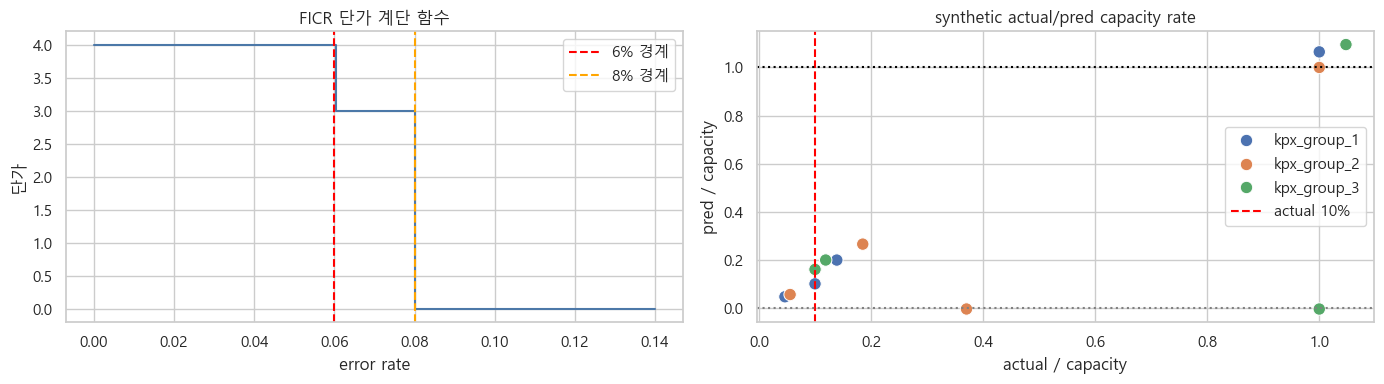

In [6]:
error_grid = np.linspace(0, 0.14, 200)
unit_price_grid = np.select([error_grid <= 0.06, error_grid <= 0.08], [4.0, 3.0], default=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].step(error_grid, unit_price_grid, where="post", color="#4C78A8")
axes[0].axvline(0.06, color="red", linestyle="--", label="6% 경계")
axes[0].axvline(0.08, color="orange", linestyle="--", label="8% 경계")
axes[0].set_title("FICR 단가 계단 함수")
axes[0].set_xlabel("error rate")
axes[0].set_ylabel("단가")
axes[0].legend()

example_long = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  for actual, pred in zip(answer_example[target], pred_example[target]):
    example_long.append(
      {
        "target": target,
        "actual_rate": actual / capacity if pd.notna(actual) else np.nan,
        "pred_rate": pred / capacity if pd.notna(pred) else np.nan,
      }
    )
example_long = pd.DataFrame(example_long)
sns.scatterplot(data=example_long, x="actual_rate", y="pred_rate", hue="target", s=80, ax=axes[1])
axes[1].axvline(0.10, color="red", linestyle="--", label="actual 10%")
axes[1].axhline(0.00, color="gray", linestyle=":")
axes[1].axhline(1.00, color="black", linestyle=":")
axes[1].set_title("synthetic actual/pred capacity rate")
axes[1].set_xlabel("actual / capacity")
axes[1].set_ylabel("pred / capacity")
axes[1].legend()
plt.tight_layout()
plt.show()

### 해석: FICR 그래프가 보여주는 최적화 방향

FICR 단가는 연속 함수가 아니라 계단 함수다. 6% 안쪽은 4원, 6~8%는 3원, 8% 밖은 0원이므로 8.1%를 8.0%로 밀어 넣는 보정은 의미가 크지만, 20% 오차를 18%로 줄이는 것은 FICR에는 직접 도움이 되지 않는다.

다만 FICR만 쫓아 bias를 과하게 움직이면 `1-NMAE`가 나빠질 수 있다. 그래서 calibration은 반드시 OOF나 holdout 내부에서만 학습하고, Public LB만 보고 조정하지 않는다.

## Decision Box 1: metric edge case 처리

| edge case | 공식 동작 | local 구현 방침 |
|---|---|---|
| `actual` NaN | valid mask에서 제외 | 동일하게 제외 |
| `pred` NaN + valid actual | NMAE가 NaN으로 전파, FICR 단가는 0 | 동일하게 전파 |
| 그룹 valid row 없음 | 공식 코드는 NaN 결과 | 경고 없이 NaN 결과를 명시적으로 반환 |
| `actual > capacity` | clipping 없이 그대로 사용 | metric에서는 그대로 사용 |
| `pred < 0` 또는 `pred > capacity` | clipping 없이 error 계산 | metric에서는 그대로 사용, 후처리는 validator 책임 |

## 3. 공식 데이터 inventory와 제출 형식 점검

원본 데이터는 `data/raw/open/`에 로컬로만 보관한다. Git에는 `README.md`와 `MANIFEST.md`만 추적하고 CSV/XLSX 원본은 stage하지 않는다.

In [7]:
required_files = [
  DATA_DIR / "data_description.md",
  DATA_DIR / "info.xlsx",
  DATA_DIR / "sample_submission.csv",
  TRAIN_DIR / "train_labels.csv",
  TRAIN_DIR / "ldaps_train.csv",
  TRAIN_DIR / "gfs_train.csv",
  TRAIN_DIR / "scada_vestas_train.csv",
  TRAIN_DIR / "scada_unison_train.csv",
  TEST_DIR / "ldaps_test.csv",
  TEST_DIR / "gfs_test.csv",
]
file_rows = []
for file_path in required_files:
  file_rows.append(
    {
      "relative_path": file_path.relative_to(PROJECT_ROOT).as_posix(),
      "exists": file_path.exists(),
      "size_mb": round(file_path.stat().st_size / 1024 / 1024, 2) if file_path.exists() else np.nan,
      "stage_policy": "원본 데이터 stage 금지",
    }
  )

pd.DataFrame(file_rows)

,relative_path,exists,size_mb,stage_policy
0,data/raw/open/data_description.md,True,0.01,원본 데이터 stage 금지
1,data/raw/open/info.xlsx,True,3.65,원본 데이터 stage 금지
2,data/raw/open/sample_submission.csv,True,0.34,원본 데이터 stage 금지
3,data/raw/open/train/train_labels.csv,True,1.09,원본 데이터 stage 금지
4,data/raw/open/train/ldaps_train.csv,True,123.68,원본 데이터 stage 금지
5,data/raw/open/train/gfs_train.csv,True,80.41,원본 데이터 stage 금지
6,data/raw/open/train/scada_vestas_train.csv,True,31.91,원본 데이터 stage 금지
7,data/raw/open/train/scada_unison_train.csv,True,16.01,원본 데이터 stage 금지
8,data/raw/open/test/ldaps_test.csv,True,41.12,원본 데이터 stage 금지
9,data/raw/open/test/gfs_test.csv,True,26.74,원본 데이터 stage 금지


### 해석: raw 데이터는 분석 근거이지만 Git 산출물이 아니다

이 inventory는 공식 파일이 로컬에 존재하는지 확인하는 단계다. 원본 CSV/XLSX는 실험의 입력 근거이지만 Git에 올릴 대상은 아니다. Git에는 manifest, 노트북, 코드, 의사결정 로그만 남기고, 원본과 생성 산출물은 로컬/outputs 규칙으로 관리한다.

다음 제출 단계에서는 이 manifest hash와 commit SHA를 submission ledger에 연결해야 같은 제출을 다시 복원할 수 있다.

In [8]:
csv_specs = [
  ("train_labels", TRAIN_DIR / "train_labels.csv", "kst_dtm", None),
  ("sample_submission", DATA_DIR / "sample_submission.csv", "forecast_kst_dtm", None),
  ("ldaps_train", TRAIN_DIR / "ldaps_train.csv", "forecast_kst_dtm", "grid_id"),
  ("gfs_train", TRAIN_DIR / "gfs_train.csv", "forecast_kst_dtm", "grid_id"),
  ("ldaps_test", TEST_DIR / "ldaps_test.csv", "forecast_kst_dtm", "grid_id"),
  ("gfs_test", TEST_DIR / "gfs_test.csv", "forecast_kst_dtm", "grid_id"),
  ("scada_vestas_train", TRAIN_DIR / "scada_vestas_train.csv", "kst_dtm", None),
  ("scada_unison_train", TRAIN_DIR / "scada_unison_train.csv", "kst_dtm", None),
]

csv_audit_rows = []
weather_grid_frames = []
for name, path, time_col, grid_col in csv_specs:
  frame = pd.read_csv(path, encoding="utf-8-sig")
  frame[time_col] = pd.to_datetime(frame[time_col])
  row = {
    "file": name,
    "rows": frame.shape[0],
    "cols": frame.shape[1],
    "start": frame[time_col].min(),
    "end": frame[time_col].max(),
    "missing_cells": int(frame.isna().sum().sum()),
    "unique_time": int(frame[time_col].nunique()),
  }
  if grid_col is not None:
    grid_count = frame.groupby(time_col)[grid_col].nunique()
    row["grid_count_min"] = int(grid_count.min())
    row["grid_count_max"] = int(grid_count.max())
    weather_grid_frames.append(
      grid_count.rename("grid_count").reset_index().assign(file=name)
    )
  else:
    row["grid_count_min"] = np.nan
    row["grid_count_max"] = np.nan
  csv_audit_rows.append(row)

csv_audit = pd.DataFrame(csv_audit_rows)
weather_grid_audit = pd.concat(weather_grid_frames, ignore_index=True)
csv_audit

,file,rows,cols,start,end,missing_cells,unique_time,grid_count_min,grid_count_max
0,train_labels,26304,4,2022-01-01 01:00:00,2025-01-01,8973,26304,NaN,NaN
1,sample_submission,8760,5,2025-01-01 01:00:00,2026-01-01,0,8760,NaN,NaN
2,ldaps_train,420864,35,2022-01-01 01:00:00,2025-01-01,0,26304,16.0,16.0
3,gfs_train,236736,40,2022-01-01 01:00:00,2025-01-01,0,26304,9.0,9.0
4,ldaps_test,140160,35,2025-01-01 01:00:00,2026-01-01,752,8760,16.0,16.0
5,gfs_test,78840,40,2025-01-01 01:00:00,2026-01-01,0,8760,9.0,9.0
6,scada_vestas_train,157819,37,2022-01-01 01:00:00,2025-01-01,0,157819,NaN,NaN
7,scada_unison_train,105264,16,2023-01-01 00:10:00,2025-01-01,9511,105264,NaN,NaN


### 해석: 결측은 label만의 문제가 아니다

전체 CSV 감사에서 `train_labels`의 target 결측뿐 아니라 `test/ldaps_test.csv`, `scada_unison_train.csv` 같은 입력 파일 결측도 확인 대상임을 알 수 있다. metric 노트북에서는 점수와 직접 연결되는 label과 제출 형식을 우선 봤지만, 모델링 전에는 weather/SCADA 결측이 feature 생성에 어떻게 전파되는지 별도 감사해야 한다.

그래서 다음 깊은 데이터 감사 노트북은 `00_official_data_audit.ipynb`가 적합하다. 이 노트북에서는 파일별 결측과 grid coverage를 잠그고, baseline 노트북에서는 모델 입력 결측을 어떻게 impute하는지 다룬다.

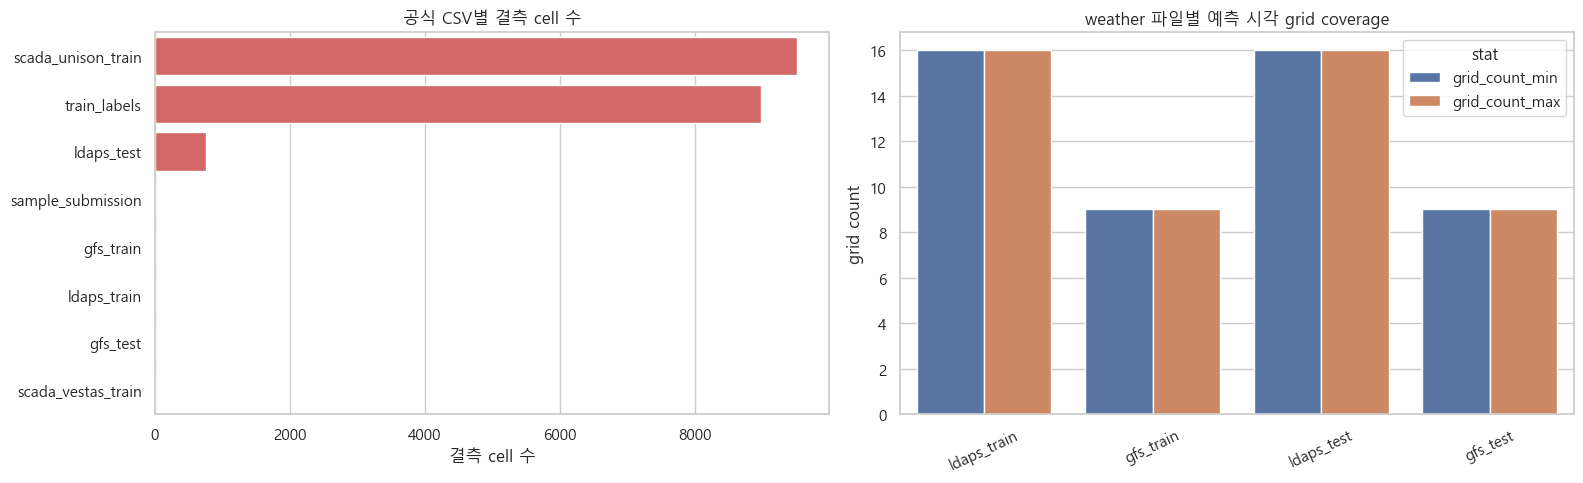

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_by_file = csv_audit.sort_values("missing_cells", ascending=False)
sns.barplot(data=missing_by_file, y="file", x="missing_cells", ax=axes[0], color="#E45756")
axes[0].set_title("공식 CSV별 결측 cell 수")
axes[0].set_xlabel("결측 cell 수")
axes[0].set_ylabel("")

grid_summary_plot = csv_audit.dropna(subset=["grid_count_min"]).copy()
grid_summary_plot = grid_summary_plot.melt(
  id_vars="file",
  value_vars=["grid_count_min", "grid_count_max"],
  var_name="stat",
  value_name="grid_count",
)
sns.barplot(data=grid_summary_plot, x="file", y="grid_count", hue="stat", ax=axes[1])
axes[1].set_title("weather 파일별 예측 시각 grid coverage")
axes[1].set_xlabel("")
axes[1].set_ylabel("grid count")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 해석: 시각화는 결측의 우선순위를 정한다

결측 cell 수 그래프는 어디를 먼저 조사해야 하는지 보여준다. 단순히 결측이 있다는 사실보다 중요한 것은, 그 결측이 평가 기간 feature 생성에 들어가는지, 학습 기간 label mask에 들어가는지, 또는 SCADA 보조 분석에만 영향을 주는지 구분하는 일이다.

grid coverage 그래프는 LDAPS 16개, GFS 9개 격자 구조가 예측 시각별로 안정적인지 확인하는 장치다. grid 수가 흔들리는 시점은 feature aggregation 결과도 흔들릴 수 있으므로 별도 표식이 필요하다.

In [10]:
train_labels = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")
train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])
sample_submission["forecast_kst_dtm"] = pd.to_datetime(sample_submission["forecast_kst_dtm"])

ldaps_meta = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig", usecols=["forecast_kst_dtm", "data_available_kst_dtm", "grid_id"])
gfs_meta = pd.read_csv(TRAIN_DIR / "gfs_train.csv", encoding="utf-8-sig", usecols=["forecast_kst_dtm", "data_available_kst_dtm", "grid_id"])
ldaps_meta["forecast_kst_dtm"] = pd.to_datetime(ldaps_meta["forecast_kst_dtm"])
ldaps_meta["data_available_kst_dtm"] = pd.to_datetime(ldaps_meta["data_available_kst_dtm"])
gfs_meta["forecast_kst_dtm"] = pd.to_datetime(gfs_meta["forecast_kst_dtm"])
gfs_meta["data_available_kst_dtm"] = pd.to_datetime(gfs_meta["data_available_kst_dtm"])

inventory = pd.DataFrame(
  [
    {"name": "train_labels", "rows": len(train_labels), "cols": train_labels.shape[1], "start": train_labels["kst_dtm"].min(), "end": train_labels["kst_dtm"].max()},
    {"name": "sample_submission", "rows": len(sample_submission), "cols": sample_submission.shape[1], "start": sample_submission["forecast_kst_dtm"].min(), "end": sample_submission["forecast_kst_dtm"].max()},
    {"name": "ldaps_train_meta", "rows": len(ldaps_meta), "cols": ldaps_meta.shape[1], "start": ldaps_meta["forecast_kst_dtm"].min(), "end": ldaps_meta["forecast_kst_dtm"].max()},
    {"name": "gfs_train_meta", "rows": len(gfs_meta), "cols": gfs_meta.shape[1], "start": gfs_meta["forecast_kst_dtm"].min(), "end": gfs_meta["forecast_kst_dtm"].max()},
  ]
)
inventory

,name,rows,cols,start,end
0,train_labels,26304,4,2022-01-01 01:00:00,2025-01-01
1,sample_submission,8760,5,2025-01-01 01:00:00,2026-01-01
2,ldaps_train_meta,420864,3,2022-01-01 01:00:00,2025-01-01
3,gfs_train_meta,236736,3,2022-01-01 01:00:00,2025-01-01


In [11]:
sample_schema = pd.DataFrame(
  {
    "column": sample_submission.columns,
    "dtype": [str(sample_submission[col].dtype) for col in sample_submission.columns],
    "missing": [int(sample_submission[col].isna().sum()) for col in sample_submission.columns],
    "role": ["ID - 변경 금지", "예측 대상 시각 - 변경 금지", "예측값 입력", "예측값 입력", "예측값 입력"],
  }
)
sample_schema

,column,dtype,missing,role
0,forecast_id,str,0,ID - 변경 금지
1,forecast_kst_dtm,datetime64[us],0,예측 대상 시각 - 변경 금지
2,kpx_group_1,int64,0,예측값 입력
3,kpx_group_2,int64,0,예측값 입력
4,kpx_group_3,int64,0,예측값 입력


### 해석: sample submission은 제출 validator의 원형이다

제출 파일에서 `forecast_id`와 `forecast_kst_dtm`은 예측 대상 식별자이므로 절대 바꾸면 안 된다. 모델은 target 3개 컬럼만 채운다. metric 함수는 세 target 컬럼만 보지만, 실제 제출 validator는 행 수, ID 순서, 시각 연속성, target NaN과 물리 범위를 함께 확인해야 한다.

이 셀은 이후 `validation.py` 또는 submission validator의 요구사항으로 그대로 옮길 수 있다.

In [12]:
expected_train_index = pd.date_range(train_labels["kst_dtm"].min(), train_labels["kst_dtm"].max(), freq="h")
expected_submission_index = pd.date_range(sample_submission["forecast_kst_dtm"].min(), sample_submission["forecast_kst_dtm"].max(), freq="h")
time_audit = pd.DataFrame(
  [
    {
      "name": "train_labels_hourly",
      "expected_rows": len(expected_train_index),
      "actual_rows": len(train_labels),
      "missing_timestamps": int(len(expected_train_index.difference(train_labels["kst_dtm"]))),
      "duplicated_timestamps": int(train_labels["kst_dtm"].duplicated().sum()),
    },
    {
      "name": "sample_submission_hourly",
      "expected_rows": len(expected_submission_index),
      "actual_rows": len(sample_submission),
      "missing_timestamps": int(len(expected_submission_index.difference(sample_submission["forecast_kst_dtm"]))),
      "duplicated_timestamps": int(sample_submission["forecast_kst_dtm"].duplicated().sum()),
    },
  ]
)
time_audit

,name,expected_rows,actual_rows,missing_timestamps,duplicated_timestamps
0,train_labels_hourly,26304,26304,0,0
1,sample_submission_hourly,8760,8760,0,0


### 해석: 시간축이 깨지면 local score도 깨진다

시간축 감사는 단순 형식 확인이 아니다. train label과 sample submission이 시간 단위로 연속인지 확인해야 weather merge, holdout split, forecast lead 계산이 모두 안정적으로 이어진다. 중복이나 누락 timestamp가 있으면 row 순서 기반 metric 비교도 위험해진다.

따라서 이후 모든 train/inference 코드는 timestamp merge 후 행 수와 순서를 반드시 검증해야 한다.

## 4. label 결측치, 범위, capacity violation 감사

공식 metric은 모든 label 행을 보지 않는다. target별로 actual이 capacity의 10% 이상인 행만 평가한다. 따라서 결측치와 valid 후보 분포를 같이 봐야 한다.

In [13]:
label_audit_rows = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  series = train_labels[target]
  valid_candidate = series >= capacity * 0.10
  label_audit_rows.append(
    {
      "target": target,
      "capacity_kwh": capacity,
      "non_null": int(series.notna().sum()),
      "missing": int(series.isna().sum()),
      "missing_pct": float(series.isna().mean()),
      "min": float(series.min(skipna=True)),
      "q25": float(series.quantile(0.25)),
      "median": float(series.quantile(0.50)),
      "q75": float(series.quantile(0.75)),
      "max": float(series.max(skipna=True)),
      "capacity_exceed": int((series > capacity).sum()),
      "negative": int((series < 0).sum()),
      "official_valid_candidate": int(valid_candidate.sum()),
      "official_valid_pct_of_non_null": float(valid_candidate.sum() / series.notna().sum()),
    }
  )
label_audit = pd.DataFrame(label_audit_rows)
label_audit

,target,capacity_kwh,non_null,missing,missing_pct,min,q25,median,q75,max,capacity_exceed,negative,official_valid_candidate,official_valid_pct_of_non_null
0,kpx_group_1,21600,26200,104,0.003954,0.0,549.600,4252.168,12206.905,21275.305,0,0,15915,0.607443
1,kpx_group_2,21600,26201,103,0.003916,0.0,549.600,4382.337,13508.589,21362.084,0,0,15891,0.606504
2,kpx_group_3,21000,17538,8766,0.333257,0.0,159.095,2719.074,9979.579,21130.674,38,0,9414,0.536777


### 해석: Group 3은 별도 전략이 필요하다

label 감사에서 가장 중요한 사실은 Group 3의 결측 구조다. Group 1/2는 거의 전체 기간이 있지만 Group 3은 2022년이 비어 있고 capacity 초과 actual도 일부 존재한다. 이 값들은 metric에서 제거되지 않으므로 학습 target 처리와 평가 계산을 분리해서 생각해야 한다.

기본 원칙은 metric 계산에는 원본 actual을 그대로 쓰고, 학습 target clipping 여부는 실험 후보로 남기는 것이다. 특히 Group 3 fold는 2023~2024 중심으로 따로 관리해야 한다.

In [14]:
label_long = train_labels.melt(id_vars="kst_dtm", value_vars=TARGET_COLS, var_name="target", value_name="actual")
label_long["capacity"] = label_long["target"].map(CAPACITY_KWH)
label_long["capacity_rate"] = label_long["actual"] / label_long["capacity"]
label_long["is_missing"] = label_long["actual"].isna()
label_long["is_official_valid"] = label_long["actual"] >= label_long["capacity"] * 0.10
label_long["year"] = label_long["kst_dtm"].dt.year
label_long["month"] = label_long["kst_dtm"].dt.to_period("M").astype(str)
label_long["hour"] = label_long["kst_dtm"].dt.hour

monthly_audit = label_long.groupby(["target", "month"]).agg(
  rows=("actual", "size"),
  missing=("is_missing", "sum"),
  valid=("is_official_valid", "sum"),
  mean_capacity_rate=("capacity_rate", "mean"),
).reset_index()
monthly_audit["missing_rate"] = monthly_audit["missing"] / monthly_audit["rows"]
monthly_audit["valid_rate"] = monthly_audit["valid"] / (monthly_audit["rows"] - monthly_audit["missing"]).replace(0, np.nan)
monthly_audit.head()

,target,month,rows,missing,valid,mean_capacity_rate,missing_rate,valid_rate
0,kpx_group_1,2022-01,743,0,520,0.370908,0.000000,0.699865
1,kpx_group_1,2022-02,672,0,511,0.431910,0.000000,0.760417
2,kpx_group_1,2022-03,744,2,470,0.291942,0.002688,0.633423
3,kpx_group_1,2022-04,720,0,513,0.348074,0.000000,0.712500
4,kpx_group_1,2022-05,744,0,546,0.351444,0.000000,0.733871


### 해석: 월별 valid 비율은 validation 설계의 근거다

월별 결측률과 valid 후보 비율은 특정 계절이나 target에서 평가에 들어가는 행의 밀도가 달라질 수 있음을 보여준다. 즉 fold를 단순히 연도 단위로만 자르면 특정 계절의 고발전/저발전 구간을 충분히 대표하지 못할 수 있다.

다음 validation 설계에서는 2024 전체 holdout을 기본으로 두되, 겨울/봄, 여름/가을, Group 3 focus fold를 따로 보는 이유가 여기서 나온다.

## 5. 데이터 감사 시각화

아래 그래프들은 metric에 직접 영향을 주는 데이터 상태만 먼저 본다.

- target별 결측 수
- 월별 결측률 heatmap
- capacity 대비 발전량 분포
- 월별 평균 capacity rate
- 월별 공식 valid 후보 비율
- 시간대별 valid 후보 비율

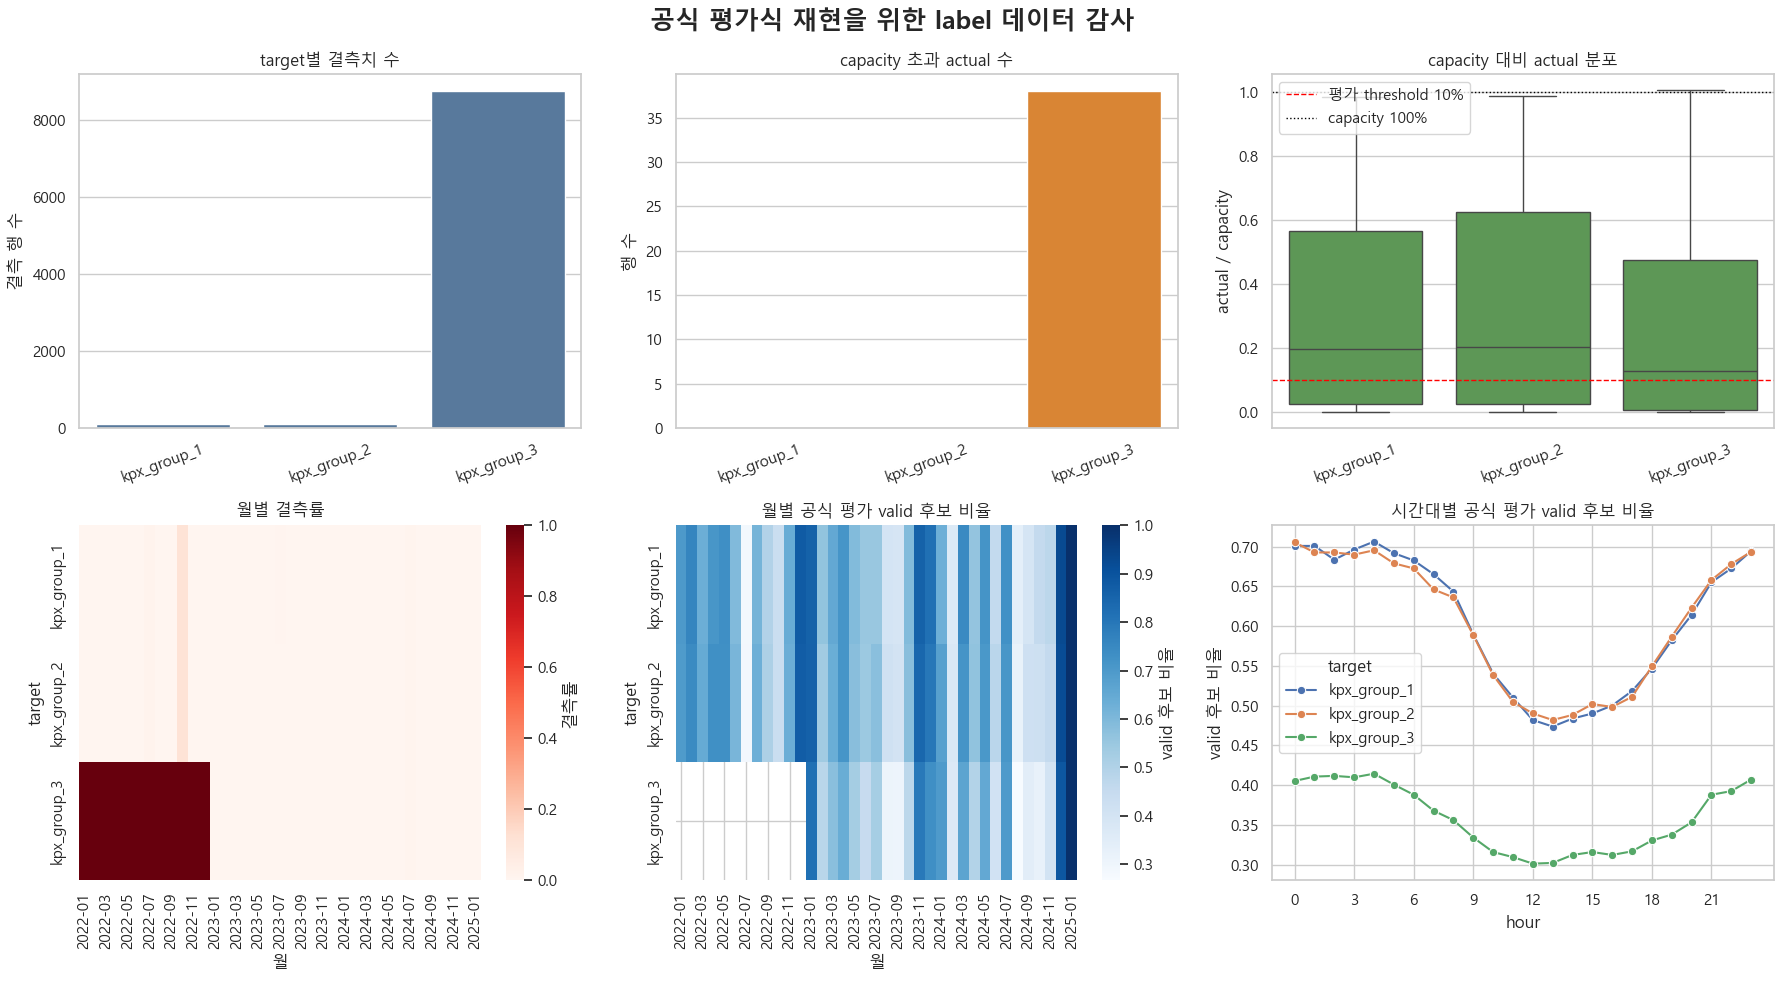

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("공식 평가식 재현을 위한 label 데이터 감사", fontsize=18, fontweight="bold")

sns.barplot(data=label_audit, x="target", y="missing", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("target별 결측치 수")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("결측 행 수")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=label_audit, x="target", y="capacity_exceed", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("capacity 초과 actual 수")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("행 수")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.boxplot(data=label_long.dropna(subset=["capacity_rate"]), x="target", y="capacity_rate", ax=axes[0, 2], color="#54A24B")
axes[0, 2].axhline(0.10, color="red", linestyle="--", linewidth=1, label="평가 threshold 10%")
axes[0, 2].axhline(1.00, color="black", linestyle=":", linewidth=1, label="capacity 100%")
axes[0, 2].set_title("capacity 대비 actual 분포")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("actual / capacity")
axes[0, 2].tick_params(axis="x", rotation=20)
axes[0, 2].legend(loc="upper left")

missing_pivot = monthly_audit.pivot(index="target", columns="month", values="missing_rate")
sns.heatmap(missing_pivot, ax=axes[1, 0], cmap="Reds", cbar_kws={"label": "결측률"})
axes[1, 0].set_title("월별 결측률")
axes[1, 0].set_xlabel("월")
axes[1, 0].set_ylabel("target")
axes[1, 0].tick_params(axis="x", rotation=90)

valid_pivot = monthly_audit.pivot(index="target", columns="month", values="valid_rate")
sns.heatmap(valid_pivot, ax=axes[1, 1], cmap="Blues", cbar_kws={"label": "valid 후보 비율"})
axes[1, 1].set_title("월별 공식 평가 valid 후보 비율")
axes[1, 1].set_xlabel("월")
axes[1, 1].set_ylabel("target")
axes[1, 1].tick_params(axis="x", rotation=90)

hourly_valid = label_long.groupby(["target", "hour"]).agg(valid_rate=("is_official_valid", "mean")).reset_index()
sns.lineplot(data=hourly_valid, x="hour", y="valid_rate", hue="target", marker="o", ax=axes[1, 2])
axes[1, 2].set_title("시간대별 공식 평가 valid 후보 비율")
axes[1, 2].set_xlabel("hour")
axes[1, 2].set_ylabel("valid 후보 비율")
axes[1, 2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

### 해석: metric이 보는 데이터와 모델이 보는 데이터는 다르다

label 감사 시각화는 전체 label 분포 중 어느 부분이 official score에 들어가는지 보여준다. 10% threshold 아래의 저발전 시간은 모델 학습에는 의미가 있을 수 있지만, 공식 점수에는 직접 반영되지 않는다. 반대로 고발전 valid 구간의 오차는 score와 FICR 양쪽에 크게 영향을 준다.

따라서 모델링 보고서에서는 전체-hour MAE와 valid-hour score를 분리해서 기록해야 한다. 한 지표만 보면 개선 방향을 잘못 잡을 수 있다.

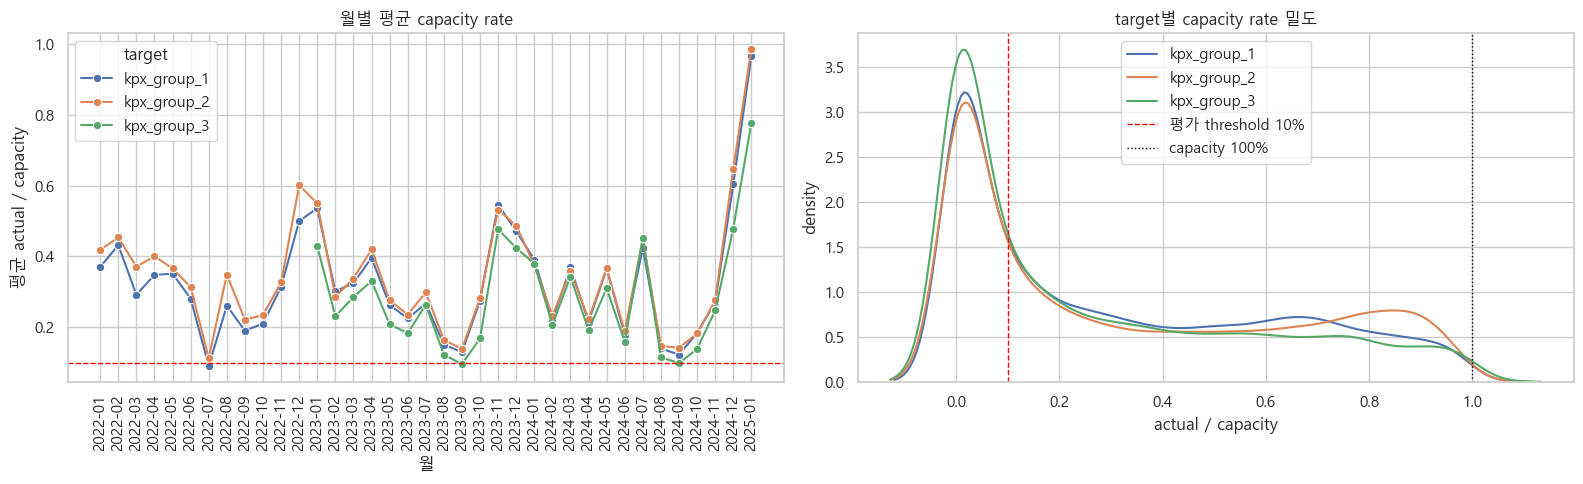

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=monthly_audit, x="month", y="mean_capacity_rate", hue="target", marker="o", ax=axes[0])
axes[0].set_title("월별 평균 capacity rate")
axes[0].set_xlabel("월")
axes[0].set_ylabel("평균 actual / capacity")
axes[0].tick_params(axis="x", rotation=90)
axes[0].axhline(0.10, color="red", linestyle="--", linewidth=1)

for target in TARGET_COLS:
  subset = label_long[(label_long["target"] == target) & label_long["actual"].notna()]
  sns.kdeplot(subset["capacity_rate"], ax=axes[1], label=target, fill=False)
axes[1].set_title("target별 capacity rate 밀도")
axes[1].set_xlabel("actual / capacity")
axes[1].set_ylabel("density")
axes[1].axvline(0.10, color="red", linestyle="--", linewidth=1, label="평가 threshold 10%")
axes[1].axvline(1.00, color="black", linestyle=":", linewidth=1, label="capacity 100%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. weather metadata와 forecast lead 감사

metric 자체는 weather를 보지 않지만, baseline과 이후 모델의 local score가 공식 평가식으로 계산되려면 예측 시각과 사용 가능 시각이 올바르게 맞아야 한다. 여기서는 grid 수와 lead hour만 확인한다.

In [17]:
def summarize_weather_meta(meta_df, name):
  grouped = meta_df.groupby("forecast_kst_dtm").agg(
    grid_count=("grid_id", "nunique"),
    available_count=("data_available_kst_dtm", "nunique"),
    data_available_kst_dtm=("data_available_kst_dtm", "first"),
  ).reset_index()
  grouped["lead_hour"] = (grouped["forecast_kst_dtm"] - grouped["data_available_kst_dtm"]).dt.total_seconds() / 3600
  return pd.Series(
    {
      "name": name,
      "forecast_rows": len(grouped),
      "grid_count_min": grouped["grid_count"].min(),
      "grid_count_max": grouped["grid_count"].max(),
      "available_count_max": grouped["available_count"].max(),
      "lead_hour_min": grouped["lead_hour"].min(),
      "lead_hour_max": grouped["lead_hour"].max(),
      "lead_hour_unique_count": grouped["lead_hour"].nunique(),
    }
  ), grouped

ldaps_summary, ldaps_grouped = summarize_weather_meta(ldaps_meta, "ldaps_train")
gfs_summary, gfs_grouped = summarize_weather_meta(gfs_meta, "gfs_train")
pd.DataFrame([ldaps_summary, gfs_summary])

,name,forecast_rows,grid_count_min,grid_count_max,available_count_max,lead_hour_min,lead_hour_max,lead_hour_unique_count
0,ldaps_train,26304,16,16,1,12.0,35.0,24
1,gfs_train,26304,9,9,1,12.0,35.0,24


### 해석: forecast lead는 leakage 방지의 기준선이다

LDAPS/GFS는 같은 예측 대상 시각이라도 `data_available_kst_dtm` 기준으로 사용 가능성이 정해진다. 이 노트북의 lead hour 감사는 feature가 미래 정보를 쓰지 않았는지 확인하는 출발점이다.

이후 feature engineering에서는 모든 파생 변수가 `forecast_kst_dtm`뿐 아니라 `data_available_kst_dtm` 기준으로도 안전한지 검증해야 한다.

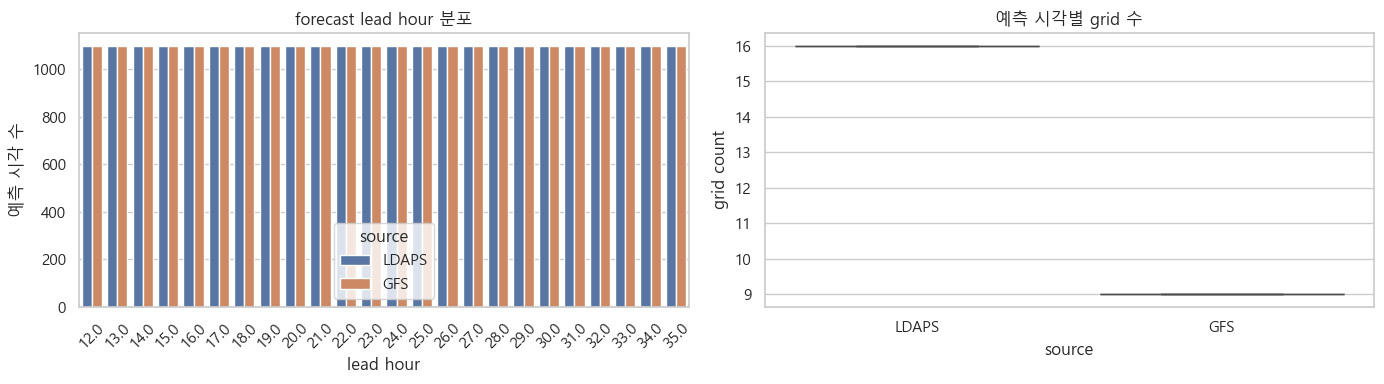

In [18]:
lead_plot_df = pd.concat(
  [
    ldaps_grouped.assign(source="LDAPS"),
    gfs_grouped.assign(source="GFS"),
  ],
  ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=lead_plot_df, x="lead_hour", hue="source", ax=axes[0])
axes[0].set_title("forecast lead hour 분포")
axes[0].set_xlabel("lead hour")
axes[0].set_ylabel("예측 시각 수")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=lead_plot_df, x="source", y="grid_count", ax=axes[1])
axes[1].set_title("예측 시각별 grid 수")
axes[1].set_xlabel("source")
axes[1].set_ylabel("grid count")

plt.tight_layout()
plt.show()

### 해석: grid coverage와 lead가 안정적이면 baseline 재현 조건이 갖춰진다

forecast lead 분포와 grid count가 공식 설명과 맞으면 baseline의 단순 평균 aggregation이 최소한 같은 입력 구조 위에서 실행된다. 이 확인 없이 모델 성능을 비교하면, feature 개선 때문인지 데이터 조인 오류 때문인지 분리할 수 없다.

다음 baseline train/inference 분리 작업에서도 이 grid count와 lead hour 검증을 smoke test로 넣는 것이 좋다.

## 7. naive holdout으로 metric 감각 확인

공식 baseline 이전에 metric의 감각을 잡기 위해 단순한 월-시간 평균 예측을 만든다. 이 모델은 성능 목적이 아니라 다음 질문을 확인하기 위한 계측점이다.

- valid mask를 적용하면 전체 MAE 감각과 얼마나 달라지는가?
- FICR가 왜 낮게 나오는가?
- target별로 error rate 분포가 어떻게 다른가?

In [19]:
train_labels_for_model = train_labels.copy()
train_labels_for_model["year"] = train_labels_for_model["kst_dtm"].dt.year
train_labels_for_model["month"] = train_labels_for_model["kst_dtm"].dt.month
train_labels_for_model["hour"] = train_labels_for_model["kst_dtm"].dt.hour

holdout_train = train_labels_for_model[train_labels_for_model["year"] < 2024].copy()
holdout_valid = train_labels_for_model[train_labels_for_model["year"] == 2024].copy()

pred_naive = pd.DataFrame(index=holdout_valid.index)
for target in TARGET_COLS:
  seasonal_mean = holdout_train.groupby(["month", "hour"])[target].mean()
  global_mean = holdout_train[target].mean()
  pred_values = []
  for _, row in holdout_valid.iterrows():
    pred_values.append(seasonal_mean.get((row["month"], row["hour"]), global_mean))
  pred_naive[target] = np.clip(pred_values, 0, CAPACITY_KWH[target])

naive_score = metric(holdout_valid[TARGET_COLS], pred_naive[TARGET_COLS])
pd.DataFrame({"metric": ["total_score", "one_minus_nmae", "ficr"], "value": naive_score})

,metric,value
0,total_score,0.433655
1,one_minus_nmae,0.748381
2,ficr,0.118929


### 해석: naive holdout은 성능 모델이 아니라 기준 감각이다

월-시간 평균 예측은 매우 단순하지만 metric의 감각을 잡는 데 유용하다. 이 score는 “아무 모델 없이 계절·시간 평균만 써도 어느 정도인지”를 보여주는 바닥선이다. 공식 RandomForest baseline은 이 값보다 높아야 하고, 개선 모델은 baseline보다 높아야 한다.

중요한 것은 이 결과를 제출 후보로 보지 않는 것이다. 이 셀은 scoring pipeline이 작동하는지 확인하는 계측 지점이다.

In [20]:
error_rows = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  actual = holdout_valid[target]
  pred = pred_naive[target]
  valid_mask = actual >= capacity * 0.10
  error_rate = (pred[valid_mask] - actual[valid_mask]).abs() / capacity
  unit_price = np.select([error_rate <= 0.06, error_rate <= 0.08], [4.0, 3.0], default=0.0)
  for value, price in zip(error_rate, unit_price):
    error_rows.append({"target": target, "error_rate": value, "ficr_unit_price": price})

error_df = pd.DataFrame(error_rows)
error_summary = error_df.groupby("target").agg(
  valid_rows=("error_rate", "size"),
  mean_error_rate=("error_rate", "mean"),
  median_error_rate=("error_rate", "median"),
  within_6pct=("error_rate", lambda x: float((x <= 0.06).mean())),
  within_8pct=("error_rate", lambda x: float((x <= 0.08).mean())),
).reset_index()
error_summary

,target,valid_rows,mean_error_rate,median_error_rate,within_6pct,within_8pct
0,kpx_group_1,4989,0.247876,0.210843,0.158148,0.208659
1,kpx_group_2,4976,0.250557,0.224069,0.142886,0.187701
2,kpx_group_3,4566,0.256423,0.204404,0.173894,0.226894


### 해석: FICR가 낮은 이유는 경계 안착률에서 보인다

naive 예측의 평균 error rate가 높고 6%/8% 안착률이 낮으면 FICR가 낮게 나온다. `1-NMAE`가 어느 정도 나와도 FICR가 낮으면 total score가 묶인다. 그래서 이후 모델은 평균 오차를 줄이는 것과 동시에 6%/8% 경계 근처의 bias를 관리해야 한다.

단, 이 보정은 validation 내부에서 검증되어야 한다. Public LB 점수만 보고 경계 보정을 하면 Private에서 무너질 수 있다.

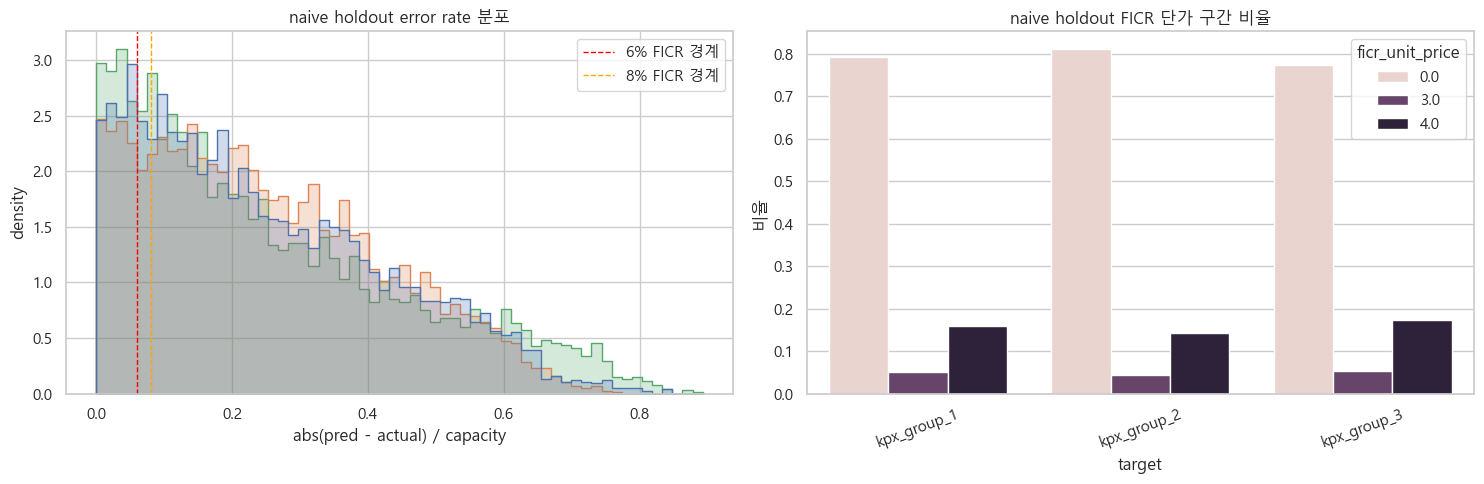

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=error_df, x="error_rate", hue="target", bins=60, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].axvline(0.06, color="red", linestyle="--", linewidth=1, label="6% FICR 경계")
axes[0].axvline(0.08, color="orange", linestyle="--", linewidth=1, label="8% FICR 경계")
axes[0].set_title("naive holdout error rate 분포")
axes[0].set_xlabel("abs(pred - actual) / capacity")
axes[0].set_ylabel("density")
axes[0].legend()

unit_price_share = error_df.groupby(["target", "ficr_unit_price"]).size().reset_index(name="rows")
unit_price_share["share"] = unit_price_share.groupby("target")["rows"].transform(lambda x: x / x.sum())
sns.barplot(data=unit_price_share, x="target", y="share", hue="ficr_unit_price", ax=axes[1])
axes[1].set_title("naive holdout FICR 단가 구간 비율")
axes[1].set_xlabel("target")
axes[1].set_ylabel("비율")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 해석: error distribution은 다음 실험의 우선순위를 정한다

error rate 분포와 FICR 단가 구간 비율은 모델 개선이 어디서 일어나야 하는지 보여준다. 분포 전체가 오른쪽에 있으면 feature/model 개선이 먼저이고, 6~10% 근처에 많이 몰려 있으면 calibration이 점수 개선에 직접적일 수 있다.

이 노트북의 결론은 metric-aware calibration을 성급히 시작하자는 것이 아니라, baseline과 GBM 실험부터 이 분포를 항상 함께 저장하자는 것이다.

## Decision Box 2: metric 관점에서 다음 모델링 기준

| 관찰 | 의미 | 다음 반영 |
|---|---|---|
| Group 3은 2022 label 대부분이 결측 | target별 학습 기간을 분리해야 한다 | baseline/GBM 모두 Group 3 fold를 별도 관리 |
| capacity 초과 actual이 Group 3에 존재 | metric에서는 그대로 점수 가중치에 들어간다 | label clipping은 실험 후보로만 두고 기본 metric은 원본 유지 |
| valid mask는 고발전 구간 중심 | 전체 MAE만 보면 official score와 어긋날 수 있다 | scoreboard에 valid-hour metric을 반드시 포함 |
| FICR는 6%/8% 근처가 핵심 | 평균 오차와 정산 구간이 서로 다를 수 있다 | calibration 실험은 OOF 기준으로 별도 관리 |
| weather lead는 12~35시간 구조 | D-1 사용 가능성 검증이 중요하다 | feature 생성 시 `data_available_kst_dtm` 기준 cutoff validator 필요 |

## 최종 결정 로그

| 날짜 | 결정 | 이유 |
|---|---|---|
| 2026-07-06 | `01_metric_reproduction.ipynb`를 공식 평가식 재현의 기준 노트북으로 추가 | `metrics.py`만으로는 데이터분석 과정과 시각화가 남지 않는다. |
| 2026-07-06 | 한글 폰트 설정을 노트북 첫 코드 셀에 포함 | 리뷰 화면에서 한글 제목과 축 라벨 깨짐을 줄인다. |
| 2026-07-06 | label 결측, capacity, valid mask를 metric 노트북에 포함 | 평가식이 실제 데이터의 어떤 행을 보는지 먼저 잠가야 한다. |
| 2026-07-06 | naive holdout은 성능 기준이 아니라 metric 감각용으로만 사용 | 공식 baseline/개선 모델은 다음 노트북과 train/inference 분리 작업에서 다룬다. |

다음 후보 작업: `00_official_data_audit.ipynb`를 별도로 만들어 weather/SCADA/info.xlsx까지 더 깊게 감사하거나, `02_official_baseline_reproduction.ipynb`의 baseline 진단 시각화를 더 보강한다.